# 04. SEOF Forecast Models

Build the forecast models from the training period.

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "manuscript.yml").exists() and (candidate / "src" / "eams_seof").exists():
            return candidate
    raise FileNotFoundError("Repository root not found.")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from eams_seof.config import load_config, resolve_path

CONFIG_PATH = REPO_ROOT / "configs" / "manuscript.yml"
cfg = load_config(CONFIG_PATH, repo_root=REPO_ROOT)

print("Repository:", REPO_ROOT)
print("Config:", CONFIG_PATH)


Repository: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_G1 복사본
Config: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_G1 복사본/configs/manuscript.yml


In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from eams_seof.preprocessing import detrend_anomaly
from eams_seof.seof import align_seof, project_seof, weighted_gram
from eams_seof.lag_weights import lag_weights as estimate_lag_weights
from eams_seof.io import save_dataset

sst_path = resolve_path(REPO_ROOT, cfg["paths"]["oisst_smoothed"])
decomp_path = resolve_path(REPO_ROOT, cfg["paths"]["seof_model"])
forecast_model_path = resolve_path(
    REPO_ROOT,
    cfg["paths"]["forecast_model"],
)
mode1_forecast_model_path = resolve_path(
    REPO_ROOT,
    cfg["paths"]["mode1_forecast_model"],
)

sst = xr.open_dataset(sst_path)["sst"].sel(
    lat=slice(*cfg["domain"]["latitude"]),
    lon=slice(*cfg["domain"]["longitude"]),
)

decomp = xr.open_dataset(decomp_path)
raw_patterns = decomp["eof_patterns"]
aligned_patterns = decomp["aligned_eof_patterns"]
seof_mean = decomp["seof_mean"]

retained_modes = int(cfg["seof"]["retained_modes"])
sea_mask = np.isfinite(sst).any("time")
training_period = tuple(cfg["periods"]["training"])

(
    detrended_sst,
    _,
    _,
    _,
) = detrend_anomaly(
    sst,
    training_period=training_period,
    sea_mask=sea_mask,
)

## Monthly dual-coordinate scores

<xarray.DataArray 'monthly_projection_score' (time: 404, mode: 3)>
array([[-15.5999775, -17.604256 ,  12.298088 ],
       [-34.81463  , -20.116169 ,  12.349242 ],
       [-43.15422  , -22.343592 ,   6.0331755],
       ...,
       [ 48.396385 , -18.80468  ,   0.2465631],
       [ 80.7112   ,   2.093227 ,  17.091894 ],
       [ 23.756018 , -52.235744 ,  -4.6684504]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1993-01-01 1993-02-01 ... 2026-08-01
  * mode     (mode) int64 1 2 3
Attributes:
    projection_method:  weighted_gram_dual

<xarray.DataArray (month: 12, mode_i: 3, mode_j: 3)>
array([[[ 9.9999994e-01, -2.4583963e-01,  4.1365853e-01],
        [-2.4583963e-01,  1.0000000e+00, -4.5779243e-04],
        [ 4.1365853e-01, -4.5779243e-04,  1.0000000e+00]],

       [[ 1.0000000e+00, -2.4017103e-01,  6.4497900e-01],
        [-2.4017103e-01,  1.0000000e+00,  1.0086610e-01],
        [ 6.4497900e-01,  1.0086610e-01,  1.0000000e+00]],

       [[ 1.0000000e+00, -5.9741002e-01,  4.9872902e-01],
        [-5.9741002e-01,  9.9999994e-01, -3.5183853e-01],
        [ 4.9872902e-01, -3.5183853e-01,  9.9999988e-01]],

       [[ 1.0000000e+00, -7.2579849e-01,  6.2703848e-01],
        [-7.2579849e-01,  1.0000000e+00, -5.0122845e-01],
        [ 6.2703848e-01, -5.0122845e-01,  1.0000000e+00]],

       [[ 9.9999994e-01, -7.1717244e-01,  4.9714872e-01],
        [-7.1717244e-01,  1.0000000e+00, -3.0560797e-01],
        [ 4.9714872e-01, -3.0560797e-01,  9.9999994e-01]],

...

       [[ 1.0000001e+00, -3.3373711e-01,  5.8885312e-01],
        [-3.3373711e-01,  1.0000000e+00,  9.4987191e-02],
        [ 5.8885312e-01,  9.4987191e-02,  1.0000001e+00]],

       [[ 1.0000000e+00,  1.6666889e-02,  6.6564220e-01],
        [ 1.6666889e-02,  9.9999982e-01,  4.2658496e-01],
        [ 6.6564220e-01,  4.2658496e-01,  9.9999994e-01]],

       [[ 9.9999994e-01, -2.8385315e-03,  8.7737000e-01],
        [-2.8385315e-03,  1.0000001e+00, -1.6171564e-03],
        [ 8.7737000e-01, -1.6171564e-03,  9.9999988e-01]],

       [[ 9.9999988e-01, -2.3042618e-01,  9.1110182e-01],
        [-2.3042618e-01,  1.0000001e+00, -2.5026447e-01],
        [ 9.1110182e-01, -2.5026447e-01,  9.9999982e-01]],

       [[ 9.9999994e-01, -3.0118272e-01,  7.2253311e-01],
        [-3.0118272e-01,  1.0000000e+00, -1.2510516e-01],
        [ 7.2253311e-01, -1.2510516e-01,  1.0000000e+00]]], dtype=float32)
Coordinates:
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * mode_i   (mode_i) int64 1 2 3
  * mode_j   (mode_j) int64 1 2 3

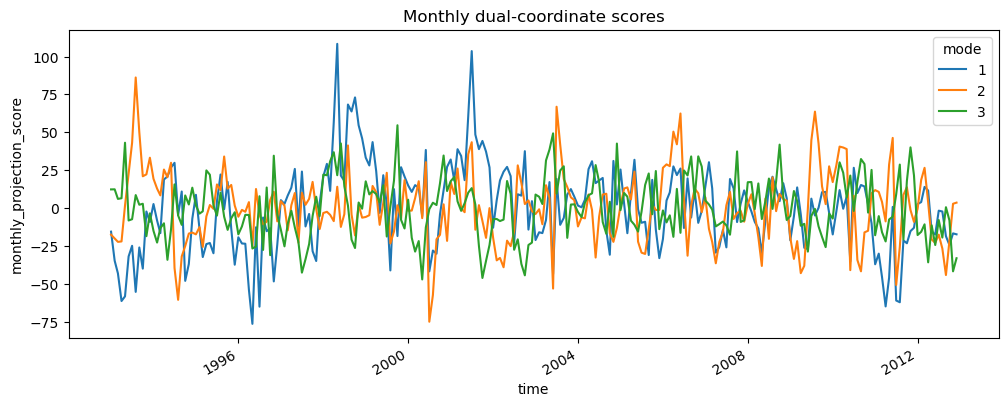

In [3]:
monthly_scores = project_seof(
    detrended_sst,
    aligned_patterns,
    seof_mean,
)

projection_gram = weighted_gram(aligned_patterns)

display(monthly_scores)
display(projection_gram)

monthly_scores.sel(
    time=slice("1993-01-01", "2012-12-31")
).plot.line(x="time", hue="mode", figsize=(12, 4))

plt.title("Monthly dual-coordinate scores")
plt.show()

## Lag-weight estimation

In [4]:
lag_model = estimate_lag_weights(
    monthly_scores=monthly_scores,
    training_period=training_period,
    maximum_lead_months=int(
        cfg["forecast"]["maximum_lead_months"]
    ),
    input_sequence_months=int(
        cfg["forecast"]["input_sequence_months"]
    ),
    shrinkage_pseudocount=int(
        cfg["forecast"]["shrinkage_pseudocount"]
    ),
    polarity_method=cfg["forecast"][
        "lag_polarity_regularization"
    ],
)

lag_weight = lag_model["lag_weight"]

display(lag_model)

print("Max |sum(|w|)-1|:")
print(
    float(
        np.abs(
            np.abs(lag_weight).sum("lag") - 1.0
        ).max()
    )
)


<xarray.Dataset>
Dimensions:                          (mode: 3, month: 12, lead: 13, lag: 12)
Coordinates:
  * mode                             (mode) int64 1 2 3
  * month                            (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * lead                             (lead) int64 0 1 2 3 4 5 6 7 8 9 10 11 12
  * lag                              (lag) int64 0 1 2 3 4 5 6 7 8 9 10 11
Data variables:
    lag_weight                       (mode, month, lead, lag) float32 0.3098 ...
    pooled_lag_correlation           (mode, lead, lag) float32 1.0 ... -0.03526
    target_month_lag_correlation     (mode, month, lead, lag) float32 1.0 ......
    training_sample_count            (mode, month, lead) int32 19 19 ... 19 19
    target_month_shrinkage_fraction  (mode, month, lead) float32 0.4419 ... 0...
Attributes:
    polarity_regularization:  lag0_nonnegative
    shrinkage_pseudocount:    24
    input_sequence_months:    12
    maximum_lead_months:      12

Max |sum(|w|)-1|:
2.384185791015625e-07


## Save the forecast model

In [5]:
forecast_model = xr.Dataset(
    {
        "monthly_projection_score": monthly_scores,
        "projection_gram": projection_gram,
        "lag_weight": lag_model["lag_weight"],
        "pooled_lag_correlation": lag_model[
            "pooled_lag_correlation"
        ],
        "target_month_lag_correlation": lag_model[
            "target_month_lag_correlation"
        ],
        "training_sample_count": lag_model[
            "training_sample_count"
        ],
        "target_month_shrinkage_fraction": lag_model[
            "target_month_shrinkage_fraction"
        ],
    },
    attrs={
        "configuration": "three_mode",
        "projection_method": "weighted_gram_dual",
        "retained_subspace_dimension": retained_modes,
        "training_start": training_period[0],
        "training_end": training_period[1],
        "input_sequence_months": int(
            cfg["forecast"]["input_sequence_months"]
        ),
        "maximum_lead_months": int(
            cfg["forecast"]["maximum_lead_months"]
        ),
        "lag_polarity_regularization": cfg[
            "forecast"
        ]["lag_polarity_regularization"],
        "shrinkage_pseudocount": int(
            cfg["forecast"]["shrinkage_pseudocount"]
        ),
    },
)

save_dataset(forecast_model, forecast_model_path)

print("Saved:", forecast_model_path)


Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_G1 복사본/outputs/model/forecast_model.nc


## Mode sensitivity

In [8]:
mode1_patterns = align_seof(
    raw_patterns.isel(mode=slice(0, 1)),
    normalize_each_month=bool(
        cfg["seof"]["normalize_aligned_monthly_patterns"]
    ),
)

if mode1_patterns.sizes["mode"] != 1:
    raise ValueError("The one-mode configuration must retain exactly one mode.")

mode1_scores = project_seof(
    detrended_sst,
    mode1_patterns,
    seof_mean,
)

mode1_projection_gram = weighted_gram(mode1_patterns)

mode1_lag_model = estimate_lag_weights(
    monthly_scores=mode1_scores,
    training_period=training_period,
    maximum_lead_months=int(
        cfg["forecast"]["maximum_lead_months"]
    ),
    input_sequence_months=int(
        cfg["forecast"]["input_sequence_months"]
    ),
    shrinkage_pseudocount=int(
        cfg["forecast"]["shrinkage_pseudocount"]
    ),
    polarity_method=cfg["forecast"][
        "lag_polarity_regularization"
    ],
)

mode1_forecast_model = xr.Dataset(
    {
        "aligned_eof_patterns": mode1_patterns,
        "monthly_projection_score": mode1_scores,
        "projection_gram": mode1_projection_gram,
        "lag_weight": mode1_lag_model["lag_weight"],
        "pooled_lag_correlation": mode1_lag_model[
            "pooled_lag_correlation"
        ],
        "target_month_lag_correlation": mode1_lag_model[
            "target_month_lag_correlation"
        ],
        "training_sample_count": mode1_lag_model[
            "training_sample_count"
        ],
        "target_month_shrinkage_fraction": mode1_lag_model[
            "target_month_shrinkage_fraction"
        ],
    },
    attrs={
        "configuration": "one_mode",
        "projection_method": "weighted_gram_dual",
        "retained_subspace_dimension": 1,
        "training_start": training_period[0],
        "training_end": training_period[1],
        "input_sequence_months": int(
            cfg["forecast"]["input_sequence_months"]
        ),
        "maximum_lead_months": int(
            cfg["forecast"]["maximum_lead_months"]
        ),
        "lag_polarity_regularization": cfg["forecast"][
            "lag_polarity_regularization"
        ],
        "shrinkage_pseudocount": int(
            cfg["forecast"]["shrinkage_pseudocount"]
        ),
    },
)

save_dataset(mode1_forecast_model, mode1_forecast_model_path)

print("Saved:", mode1_forecast_model_path)

Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_G1 복사본/outputs/model/forecast_model_mode1.nc
